# Telco Customer Churn

Predicting churn and ranking customers by risk for retention campaigns.

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## EDA

In [ ]:
# Shape and basic info
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (7043, 21)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-n

In [ ]:
# Coerce TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Numeric columns: summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# Target distribution (Churn)
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

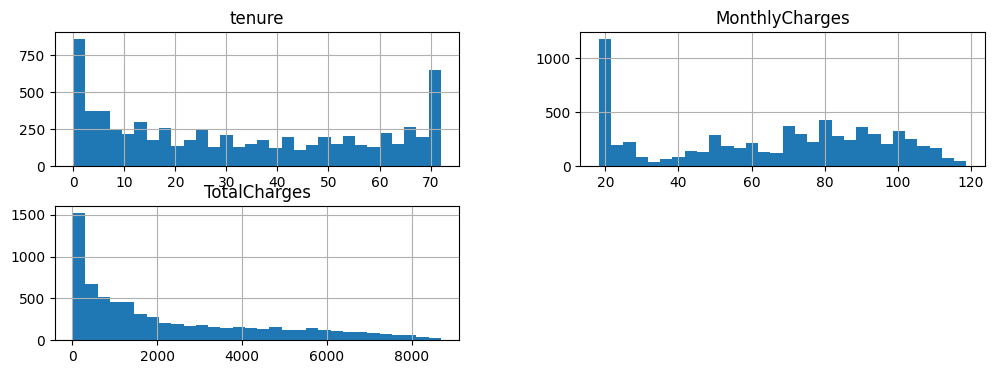

In [ ]:
# Numeric distributions
df.hist(column=["tenure", "MonthlyCharges", "TotalCharges"], figsize=(12, 4), bins=30);

In [ ]:
# Categorical columns: unique values and counts
for col in df.select_dtypes(include=["object"]).columns:
    if col == "customerID":
        continue
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport:
TechSupport
No   

/var/folders/5z/lx3dxtbx153g23s6fl4_c2q40000gp/T/ipykernel_15406/4195057520.py:2: Pandas4Warning:

For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.



In [ ]:
# Correlation of numeric features (and Churn encoded as 0/1)
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
numeric_df["Churn"] = (df["Churn"] == "Yes").astype(int)
numeric_df.corr()

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


In [ ]:
# Churn rate by key categorical variables
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\nChurn rate by {col}:")
    print(df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean().round(3)))


Churn rate by Contract:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64

Churn rate by InternetService:
InternetService
DSL            0.190
Fiber optic    0.419
No             0.074
Name: Churn, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Electronic check             0.453
Mailed check                 0.191
Name: Churn, dtype: float64


### EDA Summary

- **Dataset size:** 7,043 rows × 21 columns. No duplicate rows.

- **Target (Churn):** Class imbalance — majority did not churn; churn rate ~26% (exact share from value_counts). Important for later choice of metric and possibly resampling.

- **Missing values:** Only **TotalCharges** has missing values after coercing to numeric (empty strings become NaN). Need to handle before modeling.

- **Numeric features:** Tenure 0–72 months; MonthlyCharges and TotalCharges right-skewed. Higher tenure and higher TotalCharges tend to associate with lower churn (negative correlation with Churn).

- **Categorical:** Contract (Month-to-month / One year / Two year), InternetService (DSL / Fiber optic / No), PaymentMethod, and add-ons (e.g. OnlineSecurity, StreamingTV) show strong variation. "No phone service" / "No internet service" encode product eligibility.

- **Churn by segment:** Month-to-month contracts and Electronic check payment show higher churn rates; Two-year contracts and Fiber optic (vs No) show clear patterns. These will be useful predictors.

- **Next step:** Address missing values in TotalCharges and encoding categorical variables.

## Data preprocessing

Impute missing TotalCharges, drop identifier, encode target as binary, and encode categoricals for modeling.

In [ ]:
# Copy df
df_clean = df.copy()

# 1. Impute missing TotalCharges (fillna with 0)
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

# 2. Drop identifier
df_clean = df_clean.drop(columns=["customerID"])

# 3. Encode target: Churn 1=Yes, 0=No
df_clean["Churn"] = (df_clean["Churn"] == "Yes").astype(int)

In [ ]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### Binary Encoding

In [ ]:
# 4. Encode binary columns (Yes=1, No=0)

# Gender, Partner, Dependents

binary_cols = ["gender", "Partner", "Dependents", 'PhoneService', 'PaperlessBilling']
binary_map = {"Female": 0, "Male": 1, "Yes": 1, "No": 0}

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

# Internet add-ons (Yes=1, No / No internet service = 0)
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for col in addon_cols:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0, "No internet service": 0})

In [ ]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [ ]:
# 5. Encode Contract (ordinal: longer commitment = higher value)
df_clean["Contract"] = df_clean["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})

In [ ]:
# 6. One-hot encode nominal variables (no natural order); drop first category to avoid multicollinearity
df_clean = pd.get_dummies(df_clean, columns=['MultipleLines', "InternetService", "PaymentMethod"], drop_first=True)

In [ ]:
# Convert bool columns from get_dummies to int (some pandas versions return bool)
bool_cols = df_clean.select_dtypes(include=[bool]).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [ ]:
# 7. Verify: all columns numeric, no missing values
print("Shape:", df_clean.shape)
print("\nDtypes:")
print(df_clean.dtypes)
print("\nMissing per column:")
print(df_clean.isnull().sum().sum())  # should be 0
df_clean.head(20)

Shape: (7043, 24)

Dtypes:
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
Contract                                   int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic               

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,...,29.85,29.85,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,56.95,1889.50,0,0,0,0,0,0,0,1
2,1,0,0,0,2,1,1,1,0,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,1,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,1,0,0,1,0
5,0,0,0,0,8,1,0,0,1,0,...,99.65,820.50,1,0,1,1,0,0,1,0
6,1,0,0,1,22,1,0,1,0,0,...,89.10,1949.40,0,0,1,1,0,1,0,0
7,0,0,0,0,10,0,1,0,0,0,...,29.75,301.90,0,1,0,0,0,0,0,1
8,0,0,1,0,28,1,0,0,1,1,...,104.80,3046.05,1,0,1,1,0,0,1,0
9,1,0,0,1,62,1,1,1,0,0,...,56.15,3487.95,0,0,0,0,0,0,0,0


## Modeling

Train/validation split, baseline, Logistic Regression and Random Forest; compare with Average Precision and ROC-AUC; select best model.

## Problem Statement

**Goal:** Predict which customers are likely to churn (binary label or probability per customer).

**Use of predictions:** Prioritize retention actions (offers, outreach, product changes) for high-risk customers—e.g. target the top 20% at-risk for campaigns.

**Success:** A model that ranks customers by churn risk and supports segmenting by risk tier (High/Medium/Low) for actionable retention.

In [ ]:
# Imports and setup for modeling
# Target imbalance: handled by class_weight="balanced" and metrics (Avg Precision, ROC-AUC).
# Feature scaling: needed for Logistic Regression (scale-sensitive); RF is scale-invariant but we scale all for one pipeline.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
)
import joblib
import os

target_col = "Churn"
random_state = 42
feature_cols = [c for c in df_clean.columns if c != target_col]
X = df_clean[feature_cols]
y = df_clean[target_col]
print("Features:", len(feature_cols), "| Target balance:", y.value_counts().to_dict())

Features: 23 | Target balance: {0: 5174, 1: 1869}


In [ ]:
# Train/validation split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=random_state
)
print("Train:", X_train.shape[0], "| Val:", X_val.shape[0])

# Scale features (fit on train only; best for LR; RF scale-invariant but we scale all for one pipeline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Train: 5282 | Val: 1761


In [ ]:
# Baseline (stratified dummy) and primary metrics
# For prioritization we care about ranking: Average Precision and ROC-AUC
baseline = DummyClassifier(strategy="stratified", random_state=random_state)
baseline.fit(X_train_scaled, y_train)
y_val_pred_baseline = baseline.predict(X_val_scaled)
y_val_proba_baseline = baseline.predict_proba(X_val_scaled)[:, 1]

print("Baseline - Classification report:")
print(classification_report(y_val, y_val_pred_baseline, target_names=["No", "Yes"]))
print("Baseline - Average Precision (PR-AUC):", round(average_precision_score(y_val, y_val_proba_baseline), 4))
print("Baseline - ROC-AUC:", round(roc_auc_score(y_val, y_val_proba_baseline), 4))

Baseline - Classification report:
              precision    recall  f1-score   support

          No       0.75      0.75      0.75      1294
         Yes       0.30      0.29      0.29       467

    accuracy                           0.63      1761
   macro avg       0.52      0.52      0.52      1761
weighted avg       0.63      0.63      0.63      1761

Baseline - Average Precision (PR-AUC): 0.274
Baseline - ROC-AUC: 0.5203


In [ ]:
# Train Logistic Regression and Random Forest (on scaled data)
lr = LogisticRegression(max_iter=1000, random_state=random_state, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=random_state, class_weight="balanced")
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
# Compare models (Average Precision + ROC-AUC)
def eval_model(name, y_true, y_proba, y_pred):
    ap = average_precision_score(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    print(f"{name}: Avg Precision = {ap:.4f}, ROC-AUC = {auc:.4f}")
    return ap, auc

y_val_proba_lr = lr.predict_proba(X_val_scaled)[:, 1]
y_val_proba_rf = rf.predict_proba(X_val_scaled)[:, 1]

eval_model("Baseline", y_val, y_val_proba_baseline, y_val_pred_baseline)
eval_model("Logistic Regression", y_val, y_val_proba_lr, lr.predict(X_val_scaled))
eval_model("Random Forest", y_val, y_val_proba_rf, rf.predict(X_val_scaled))

Baseline: Avg Precision = 0.2740, ROC-AUC = 0.5203
Logistic Regression: Avg Precision = 0.6344, ROC-AUC = 0.8461
Random Forest: Avg Precision = 0.6409, ROC-AUC = 0.8425


(0.6409347314503582, 0.8424717606214154)

In [ ]:
# Best model: use the one with higher Average Precision (good for imbalanced ranking)
ap_lr = average_precision_score(y_val, y_val_proba_lr)
ap_rf = average_precision_score(y_val, y_val_proba_rf)
best_model = lr if ap_lr >= ap_rf else rf
best_name = "Logistic Regression" if ap_lr >= ap_rf else "Random Forest"
print("Best model:", best_name)
print(classification_report(y_val, best_model.predict(X_val_scaled), target_names=["No", "Yes"]))
print("Confusion matrix:\n", confusion_matrix(y_val, best_model.predict(X_val_scaled)))

Best model: Random Forest
              precision    recall  f1-score   support

          No       0.88      0.80      0.84      1294
         Yes       0.56      0.69      0.62       467

    accuracy                           0.77      1761
   macro avg       0.72      0.74      0.73      1761
weighted avg       0.79      0.77      0.78      1761

Confusion matrix:
 [[1041  253]
 [ 147  320]]


### Confusion Matrix (Validation Set)

Predicted No	   Predicted Yes
Actual No	1,041	 253
Actual Yes	147	     320


Key takeaways
69% of churners are correctly identified

The model intentionally sacrifices some precision to catch more at-risk customers

This is the right trade-off for retention use cases

Missing a churner is usually more expensive than contacting a customer who would have stayed anyway.

### Feature importance

Top drivers of churn (model coefficients or tree importances).

In [ ]:
# Feature importance (coefficients for LR; importances for RF) — interactive plot
import plotly.express as px

if best_name == "Logistic Regression":
    imp = pd.Series(best_model.coef_.ravel(), index=feature_cols).abs().sort_values(ascending=False)
else:
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 15 features (importance):")
print(imp.head(15).to_string())

imp_top = imp.head(15).reset_index()
imp_top.columns = ["feature", "importance"]
fig = px.bar(imp_top, x="importance", y="feature", orientation="h", title=f"Top 15 features ({best_name})",
             labels={"importance": "Importance", "feature": "Feature"}, text_auto=".3f")
fig.update_layout(yaxis={"categoryorder": "total ascending"}, height=500, margin=dict(l=120))
fig.update_traces(textposition="outside")
fig.show()

Top 15 features (importance):
Contract                          0.172869
tenure                            0.164469
TotalCharges                      0.133977
MonthlyCharges                    0.124981
InternetService_Fiber optic       0.074840
PaymentMethod_Electronic check    0.053056
InternetService_No                0.032143
PaperlessBilling                  0.029980
TechSupport                       0.024918
OnlineSecurity                    0.024349
Dependents                        0.017833
gender                            0.016263
OnlineBackup                      0.015794
Partner                           0.015245
StreamingMovies                   0.014925


## Churn Probability and Risk Tier for prioritization



In [ ]:
# Actionable output: churn probability and risk tier for prioritization
churn_proba = best_model.predict_proba(X_val_scaled)[:, 1]
risk_tier = np.where(churn_proba >= 0.6, "High", np.where(churn_proba >= 0.3, "Medium", "Low"))

# Rank customers by risk (highest first)
ranked = pd.DataFrame({
    "churn_probability": churn_proba,
    "risk_tier": risk_tier,
    "churn_actual": y_val.values,
}).sort_values("churn_probability", ascending=False).reset_index(drop=True)
ranked["rank"] = ranked.index + 1

# Top 20% at-risk (for retention campaigns)
n_top20 = max(1, int(0.2 * len(ranked)))
top20 = ranked.head(n_top20)
print("Top 20% at-risk: count =", len(top20), "| Churn rate in this segment =", top20["churn_actual"].mean().round(2))
print("\nRisk tier counts (validation set):")
print(ranked["risk_tier"].value_counts().sort_index())
ranked.head(10)

Top 20% at-risk: count = 352 | Churn rate in this segment = 0.67

Risk tier counts (validation set):
risk_tier
High      438
Low       923
Medium    400
Name: count, dtype: int64


,churn_probability,risk_tier,churn_actual,rank
0,0.961110,High,1,1
1,0.952422,High,1,2
2,0.950805,High,1,3
3,0.945740,High,1,4
4,0.943883,High,1,5
5,0.943420,High,1,6
6,0.940611,High,1,7
7,0.937954,High,0,8
8,0.937148,High,1,9
9,0.935780,High,1,10


In [ ]:
# Retrain best model on full data (train + val) and save for deployment
X_full = X
y_full = y
scaler_final = StandardScaler()
X_full_scaled = scaler_final.fit_transform(X_full)

best_model_final = LogisticRegression(max_iter=1000, random_state=random_state, class_weight="balanced") if best_name == "Logistic Regression" else RandomForestClassifier(n_estimators=100, max_depth=10, random_state=random_state, class_weight="balanced")
best_model_final.fit(X_full_scaled, y_full)

os.makedirs("../models", exist_ok=True)
joblib.dump(
    {"model": best_model_final, "scaler": scaler_final, "feature_cols": feature_cols, "target_col": target_col},
    "../models/churn_model.joblib",
)
print("Saved: ../models/churn_model.joblib (model + scaler + feature_cols + target_col)")

Saved: ../models/churn_model.joblib (model + scaler + feature_cols + target_col)


---

## Results summary

| **Aspect** | **Result** |
|------------|------------|
| **Data** | 7,043 customers × 21 columns (raw) → 23 features after preprocessing. Target: 73% No churn, 27% Yes (imbalanced). |
| **Split** | Train: 5,282 · Validation: 1,761 (stratified 75/25). Features scaled with `StandardScaler` (fit on train only). |
| **Baseline** | Stratified dummy: Average Precision ≈ 0.27, ROC-AUC ≈ 0.52. |
| **Models** | **Logistic Regression:** AP ≈ 0.63–0.64, ROC-AUC ≈ 0.85. **Random Forest:** AP ≈ 0.64, ROC-AUC ≈ 0.84. |
| **Best model** | **Random Forest** (higher Average Precision). Validation: precision No 0.88 / Yes 0.56, recall No 0.80 / Yes 0.69, accuracy 0.77. |
| **Actionable output** | Customers ranked by churn probability. **Top 20% at-risk:** 352 customers, **67% churn rate** in that segment (vs ~27% overall). Risk tiers: High (438), Medium (400), Low (923). |
| **Artifact** | `models/churn_model.joblib`: trained model, scaler, `feature_cols`, `target_col` for scoring new customers. |

**Takeaway:** The model identifies a high-risk segment (top 20%) with ~2.5× the overall churn rate, suitable for prioritising retention campaigns (offers, outreach, product changes).

---

**Summary for leadership — what's driving churn?**

The model ranks each driver by how much it predicts churn. Below are the **top drivers from the model** (feature importance), in order, and what to do about them.

| **Rank** | **Driver (from model)** | **Importance** | **What it means** |
|----------|--------------------------|----------------|-------------------|
| 1 | **Contract** | 17.3% | Month-to-month vs 1-year vs 2-year. This is the single strongest predictor: short-term contracts churn more. |
| 2 | **tenure** | 16.4% | Months with the company. Newer customers are riskier. |
| 3 | **TotalCharges** | 13.4% | Total amount paid to date. Lower total spend = higher risk (often overlaps with short tenure). |
| 4 | **MonthlyCharges** | 12.5% | Current monthly bill. Higher bills are associated with more churn (price/value sensitivity). |
| 5 | **InternetService_Fiber optic** | 7.5% | Having fiber (vs DSL or no internet). Product type strongly separates risk. |
| 6 | **PaymentMethod_Electronic check** | 5.3% | Paying by electronic check (vs auto, card, mailed). This payment method is linked to more churn. |
| 7 | **InternetService_No** | 3.2% | No internet product (phone-only, etc.). Defines a distinct at-risk segment. |
| 8 | **PaperlessBilling** | 3.0% | Has paperless billing or not. Contributes to risk profile. |
| 9–10 | **TechSupport**, **OnlineSecurity** | ~2.5% each | Having these add-ons is associated with *lower* churn (stickier customers). |
| 11–15 | **Dependents**, **gender**, **OnlineBackup**, **Partner**, **StreamingMovies** | ~1.5–1.8% each | Smaller but consistent signals; add-ons and household structure. |

**Explicit takeaways from these results:**

1. **Contract** (17.3%) and **tenure** (16.4%) dominate — together they account for about one-third of the model’s signal. **Action:** Prioritise moving at-risk customers off month-to-month onto 1- or 2-year plans, and concentrate retention effort on newer customers (low tenure).

2. **TotalCharges** (13.4%) and **MonthlyCharges** (12.5%) are the next largest. **Action:** For high-risk customers with high monthly charges, improve perceived value (bundles, discounts). For those with low total spend (often new), strengthen the early experience so they stay and grow spend.

3. **InternetService** (Fiber 7.5%, No 3.2%) and **PaymentMethod_Electronic check** (5.3%) are the next clearest levers. **Action:** Tailor retention by product (fiber vs DSL vs no internet). Nudge electronic-check payers to auto-pay to reduce friction and churn.

4. **TechSupport** and **OnlineSecurity** (each ~2.5%) are the most important *protective* factors. **Action:** Promote or bundle tech support and online security for at-risk segments; they are retention levers, not just revenue.

5. **PaperlessBilling**, **Dependents**, **Partner**, **OnlineBackup**, **StreamingMovies**, and **gender** have smaller but non-zero importance. **Action:** Use for segmenting and targeting; no single “silver bullet” but they help refine who gets which offer.

**Bottom line:** The model’s top four features — **Contract**, **tenure**, **TotalCharges**, **MonthlyCharges** — account for about 60% of the explained importance. Focus retention on contract type and tenure first, then on charges and value, then on payment method and product (internet type), and use add-ons (TechSupport, OnlineSecurity) as retention tools for the top 20% at-risk.